In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as mlt

In [2]:
df  = pd.read_csv(".\\bank_churn.csv")  

In [3]:
x = df.drop(["Exited"] , axis=1)
y = df["Exited"] 

In [4]:
x = np.array(x)
y = np.array(y)

In [5]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
scaler.fit_transform(x)

array([[-1.69774938,  0.2792881 , -1.33333333,  0.90863549,  0.90242325,
        -1.33978769,  0.92295821],
       [-1.62845348,  0.16482577, -1.33333333,  0.31050967,  1.33460372,
        -1.33978769, -1.08347268],
       [-1.55915759,  0.2792881 , -1.33333333,  1.41190161,  1.38823054,
         2.60076434,  0.92295821],
       [-1.4898617 , -0.06409891, -1.33333333, -0.90637501,  0.61201218,
         0.63048832, -1.08347268],
       [-1.4205658 ,  0.39375044, -1.33333333,  0.91604074,  0.04284972,
        -1.33978769, -1.08347268],
       [-1.35126991,  0.50821278,  0.75      ,  0.511729  ,  1.21449353,
         0.63048832,  0.92295821],
       [-1.28197402,  1.1949868 ,  0.75      ,  0.96867604, -1.385616  ,
         0.63048832,  0.92295821],
       [-1.21267813, -1.20872228, -1.33333333, -0.90637501,  2.17000849,
         0.63048832, -1.08347268],
       [-1.14338223,  0.50821278,  0.75      ,  0.90863549,  1.49521394,
         0.63048832, -1.08347268],
       [-1.07408634, -1.4376

In [6]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(x , y , test_size=0.2)

In [7]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(max_depth=7,min_samples_split=3 , random_state=42)
model.fit(X_train , Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [8]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [9]:
from sklearn.metrics import confusion_matrix , roc_auc_score , accuracy_score
ra = roc_auc_score(Y_test , y_pred_test)
ra

0.6666666666666666

In [10]:
c = confusion_matrix(Y_test , y_pred_test)
c

array([[7, 0],
       [2, 1]])

In [11]:
a_train = accuracy_score(Y_train, y_pred_train )
a_test = accuracy_score(Y_test , y_pred_test)
a_train , a_test

(1.0, 0.8)

In [12]:
from sklearn.metrics import recall_score , precision_score
r = recall_score(Y_test , y_pred_test)
r

0.3333333333333333

In [13]:
p = precision_score(Y_test , y_pred_test)
p

1.0

In [14]:
df.head()

,RowNumber,Age,Gender,Balance,EstimatedSalary,NumOfProducts,IsActiveMember,Exited
0,1,42,0,125000,101348,1,1,1
1,2,41,0,83807,112542,1,0,0
2,3,42,0,159660,113931,3,1,0
3,4,39,0,0,93826,2,0,0
4,5,43,0,125510,79084,1,0,0


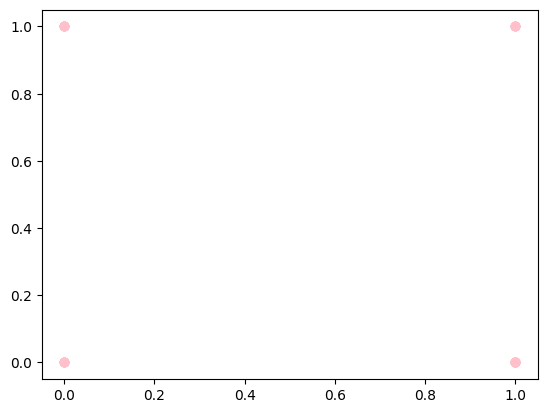

In [15]:
rm = df["RowNumber"]
am = df["Age"]
gm = df["Gender"]
bm = df["Balance"]
im = df["IsActiveMember"] 

mlt.plot(gm , y , "o", color="pink")
mlt.show()

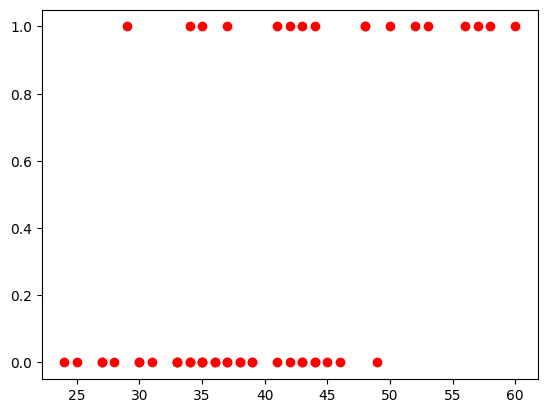

In [16]:
mlt.plot(am, y , "o" , color="red")
mlt.show()

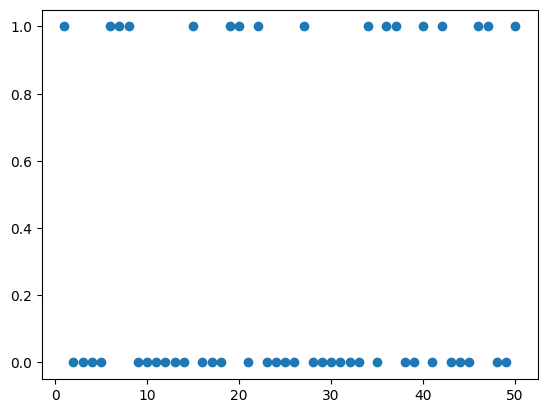

In [17]:
mlt.plot(rm , y , "o")
mlt.show()

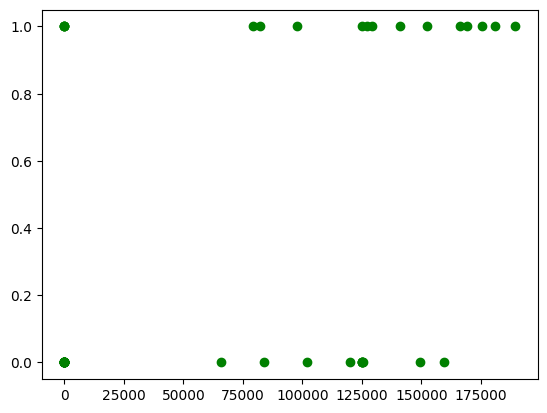

In [18]:
mlt.plot(bm , y ,"o", color= "g")
mlt.show()

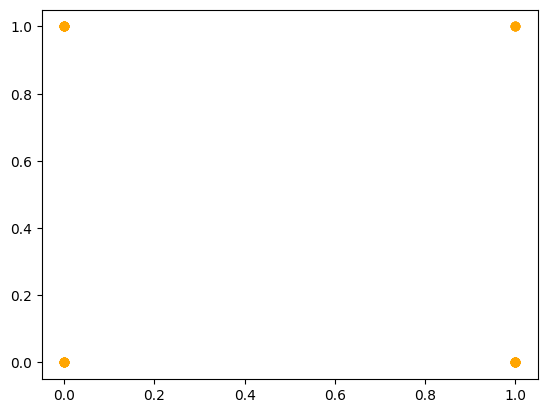

In [19]:
mlt.plot(im , y , "o" , color="orange")
mlt.show()

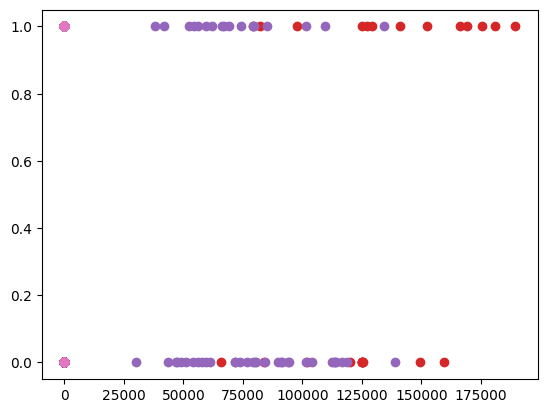

In [20]:
mlt.plot(x , y, "o",)
mlt.show()

In [21]:
d = {
    "RowNumber" : np.random.randint(1,4),
    "Age" : np.random.randint(35,50),
    "Gender" : np.random.randint(0,2),
    "Balance" : np.random.randint(20000,50000),
    "EstimatedSalary" : np.random.randint(100000,200000),
    "NumOfProducts" : np.random.randint(1,4),
    "IsActiveMember" : np.random.randint(0,2)
}

In [22]:
df["Exited"].value_counts()

Exited
0    33
1    17
Name: count, dtype: int64

In [23]:
rdf = pd.DataFrame(d, index=[0])
result_model = model.predict(rdf)

c:\Users\mahan.ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [25]:
if result_model == [1]:
    print("Yes")
else:
    print("No")

No
